# 04_概率分布-伽玛分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天，和大家来聊聊伽玛分布\~

伽玛分布（Gamma Distribution）是一种连续概率分布，经常用于描述一段时间或一段距离内随机事件发生所等待的时间。

也就是说，伽玛分布可以看成是多个指数分布随机变量（即描述单次事件等待时间的分布）的和。例如：

- **排队现象：** 在一个银行或快餐店中，顾客到达的时间间隔可能服从指数分布。当我们考虑等待一段连续时间内有多个顾客到达时，这个等待时间的分布就可以用伽玛分布来描述。
- **设备故障：** 假设每台机器的单个部件发生故障的时间服从指数分布，那么整个系统在经历几个部件依次故障后的总运行时间就服从伽玛分布。
- **自然现象：** 某些自然事件（如地震）的发生间隔可以用伽玛分布进行建模，用以描述在给定时间内可能经历的多次事件。

从这些例子可以看出，伽玛分布通常用于描述“累积等待时间”或“连续事件发生累积的效果”，其核心思想是将单个独立的随机等待时间累加成总等待时间。

### 伽玛分布的本质

伽玛分布的本质在于其参数化的灵活性。

伽玛分布主要由两个参数决定：

- **形状参数（shape parameter）k（或称为α）：** 控制分布的形状。当 k=1 时，伽玛分布退化为指数分布。随着 k 的增大，分布的形状会逐渐变得更加对称，呈现出类似于正态分布的“钟形”，但仍具有偏态特征。
- **尺度参数（scale parameter）θ（或称为β）：** 控制分布的伸缩。当 θ 变大时，分布的扩散程度增大，图形向右拉长；当 θ 变小时，分布变得更集中。

伽玛分布的概率密度函数（Probability Density Function, PDF）形式为：


$$
f(x; k,\theta) = \frac{x^{k-1} e^{-x/\theta}}{\theta^k \Gamma(k)}, \quad x > 0,
$$


其中 $\Gamma(k)$ 表示伽玛函数，是对阶乘函数的一种推广（当 k 为正整数时，$\Gamma(k)= (k-1)!$）。

本质上，伽玛分布描述的是一个“累加随机事件”的概率特征，比如累加 k 个独立同分布的指数随机变量的和，其结果的分布就是伽玛分布。这也解释了为什么伽玛分布在建模等待多个独立随机事件的总时延时非常有用。

### 伽玛分布的特点

伽玛分布具有以下几个重要特点：

1. **支持域为正实数：** 伽玛分布定义在 $x > 0$的范围内，因此只能描述非负的连续随机变量，如时间、距离或其他正值量。
2. **偏态分布：** 伽玛分布通常是不对称的，即存在正偏。分布在低值处呈陡峭下降，而在高值尾部则表现出较长的尾部特性。仅当参数适当取值时，分布可能接近对称，但严格来说伽玛分布通常仍保留正偏特性。
3. **参数解释明确：**

   - **形状参数 k：** 当 k=1 时，伽玛分布变为指数分布，表示单次事件等待时间。
   - **尺度参数 θ：** 描述事件发生等待时间的平均尺度，反映了时间尺度的长短。
4. **广泛应用：**

   - 可用于描述等待时间或发生频率的累积效应
   - 常见于排队理论、可靠性工程、保险精算、统计数据拟合等领域

## 公式推导

在这一节中，我们将深入探讨伽玛分布的数学公式，并详细解释其推导过程。虽然推导过程中涉及一些高级数学概念，但我会尽可能用通俗易懂的语言讲解每一步的原理\~

### 伽玛函数的基本概念

伽玛函数 $\Gamma(z)$ 是一个在复平面上定义的函数，在实数领域对正整数具有很好的解释（比如 $\Gamma(n) = (n-1)!$）。伽玛函数的定义为：


$$
\Gamma(z) = \int_0^{\infty} x^{z-1} e^{-x} \, dx,\quad z>0.
$$


该积分收敛，并且当 $z$ 为正整数时，可以证明该函数等于阶乘的延拓形式。

#### 伽玛函数性质

伽玛函数具有以下几个重要性质：

- **递推关系：**


$$
\Gamma(z+1) = z\Gamma(z)
$$


- 这一关系使得对于正整数 $n$，有 $\Gamma(n+1)=n!$。
- **归一化与收敛性：**当 $z>0$ 时积分收敛，确保了伽玛函数在定义域内的良好行为。

### 伽玛分布的概率密度函数（PDF）的推导

伽玛分布的概率密度函数给出为：


$$
f(x; k,\theta) = \frac{x^{k-1} e^{-x/\theta}}{\theta^k \, \Gamma(k)}, \quad x > 0,
$$


其中参数 $k$ 为形状参数，$\theta$ 为尺度参数。

#### 推导过程说明

##### 1）起始点：对独立指数分布的求和

设 $X_i$ 是一组相互独立且服从参数为 $\lambda$ 的指数分布的随机变量，其概率密度函数为：


$$
f_{X}(x) = \lambda e^{-\lambda x},\quad x \ge 0.
$$


如果令 $Y = \sum_{i=1}^{k} X_i$，根据卷积定理，多次卷积之后的分布即为伽玛分布。注意，当 $\lambda = 1/\theta$ 时，$f_{X}(x)$ 可写为：


$$
f_{X}(x) = \frac{1}{\theta}e^{-x/\theta}.
$$


##### 2）卷积求和：利用卷积定理

我们知道卷积积分的形式为：


$$
f_Y(y) = \int_0^y f_{X_1}(x) f_{Y-X_1}(y-x)\, dx.
$$


通过反复应用卷积，会得到如下形式：


$$
f_Y(y) = \frac{1}{\theta^k} \frac{y^{k-1} e^{-y/\theta}}{(k-1)!},
$$


这正是伽玛分布的概率密度函数，其中 $(k-1)! = \Gamma(k)$ 当 $k$ 为正整数时。这一结果可以通过数学归纳法严谨证明，且推导中必须引入伽玛函数以扩展到非整数 k 值。

##### 3）常数因子的确定

为了确保概率密度函数在全范围内积分为 1，需要引入归一化常数。计算归一化常数的方法为：


$$
\int_0^{\infty} x^{k-1} e^{-x/\theta} \, dx = \theta^k \Gamma(k),
$$


因此，


$$
\frac{1}{\theta^k \Gamma(k)} \int_0^{\infty} x^{k-1} e^{-x/\theta} \, dx = 1.
$$


这保证了概率密度函数的正确归一化。

### 累积分布函数（CDF）

伽玛分布的累积分布函数 $F(x; k,\theta)$ 表示随机变量 $X$ 小于等于 $x$ 的概率，其表达式为：


$$
F(x; k,\theta) = \frac{1}{\Gamma(k)} \gamma\left(k, \frac{x}{\theta}\right),
$$


其中 $\gamma(s, x)$ 是不完全伽玛函数，定义为


$$
\gamma(s,x) = \int_0^{x} t^{s-1} e^{-t} \, dt.
$$


这个累积分布函数表达了在给定 $x$ 内累计的概率，通常用数值方法计算。

### 矩（Moments）与期望

#### 均值（数学期望）

对于伽玛分布，其均值可以证明为：


$$
E[X] = k\theta.
$$


这一结论可以利用概率密度函数积分计算，即：


$$
E[X] = \int_0^{\infty} x f(x; k,\theta) \, dx = \frac{1}{\theta^k \Gamma(k)} \int_0^{\infty} x^k e^{-x/\theta} \, dx.
$$


利用变量代换 $u=x/\theta$ 可得：


$$
E[X] = k\theta.
$$


#### 方差

伽玛分布的方差为：


$$
\mathrm{Var}(X) = k\theta^2.
$$


证明过程与均值类似，利用对 $x^2$ 的积分计算得到。步骤如下：先计算 $E[X^2]$，再利用 $\mathrm{Var}(X) = E[X^2] - (E[X])^2$，最终得到该结果。

通过上述推导，我们可以归纳出伽玛分布的几个核心数学结果：

概率密度函数：


$$
f(x; k,\theta) = \frac{x^{k-1} e^{-x/\theta}}{\theta^k \Gamma(k)}, \quad x > 0.
$$


累积分布函数：


$$
F(x; k,\theta) = \frac{1}{\Gamma(k)} \gamma\left(k, \frac{x}{\theta}\right).
$$


均值和方差分别为 $k\theta$和 $k\theta^2$。

这些结果不仅在数学上成立，也是很多实际应用（例如排队模型和可靠性分析）的理论基础。

## Python 实现

这里，介绍如何使用 Python 生成伽玛分布数据、可视化伽玛分布，并展示一个基于伽玛分布的机器学习算法应用示例。

#### 数据生成与可视化

我们将利用 Python 中的 NumPy 和 Matplotlib 库生成伽玛分布数据，并通过绘图展示分布形态。

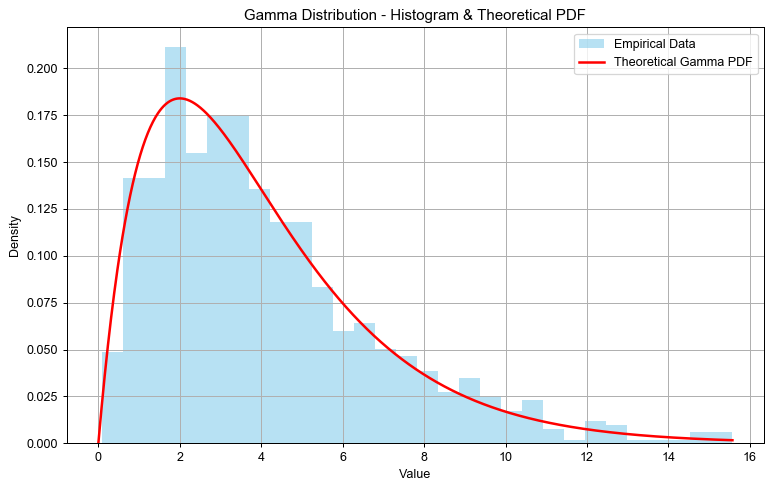

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

np.random.seed(42)

# Gamma分布参数
shape = 2.0
scale = 2.0

# 从Gamma分布生成样本数据
sample_size = 1000
data = np.random.gamma(shape, scale, sample_size)

# 绘制伽玛分布的直方图
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', label='Empirical Data')

# 计算理论概率密度
x = np.linspace(0, np.max(data), 1000)
pdf = gamma.pdf(x, a=shape, scale=scale)

# 在直方图上绘制理论概率密度曲线
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical Gamma PDF')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Gamma Distribution - Histogram & Theoretical PDF')
plt.legend()
plt.grid(True)
plt.show()

首先我们设定了伽玛分布的形状参数 (k) 和尺度参数 (θ)。

接着通过 `np.random.gamma` 方法生成样本数据，并利用 Matplotlib 绘制直方图以及由 SciPy 中 gamma.pdf 计算得到的理论概率密度曲线，从而直观地展示了伽玛分布的形状和特征。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

### 机器学习算法应用示例

伽玛分布在机器学习中有着广泛应用，尤其是在处理涉及等待时间、可靠性和生存分析等方面的任务。

下面咱们利用伽玛分布来建立回归模型。伽玛回归模型常用于响应变量为正值且呈现右偏分布的数据（例如保险赔付、医学数据中的生存时间等）。

#### 数据准备

首先我们模拟一组数据，其中因变量服从伽玛分布，并且与一个自变量呈现某种非线性关系。我们利用 scikit-learn 构建并训练模型：

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import TweedieRegressor

np.random.seed(42)

# 生成模拟数据: X 为自变量，y 为因变量，y 服从伽玛分布
n_samples = 1000
X = np.random.uniform(0, 10, n_samples).reshape(-1, 1)
# 这里构建 y 的真实模型： y = a*X^2 + b + 噪声，其中噪声服从Gamma分布
a, b = 0.5, 2.0
# 生成带有伽玛噪声的目标值
noise = np.random.gamma(shape=2.0, scale=2.0, size=n_samples)
y = a * X.flatten()**2 + b + noise

# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

在这段代码中，我们构造了一个非线性关系的数据集，其中目标变量 y 与自变量 X 的关系为 $y = 0.5X^2 + 2$加上一部分服从伽玛分布的噪声。这样的数据生成方式在很多实际应用中都能反映出右偏特性。

#### 模型训练与预测

接下来我们采用 Tweedie 回归器进行建模。Tweedie 回归器能够处理依赖于伽玛分布的回归问题；选择分布参数为2则相当于伽玛分布。

Mean Squared Error: 7.977608085110567


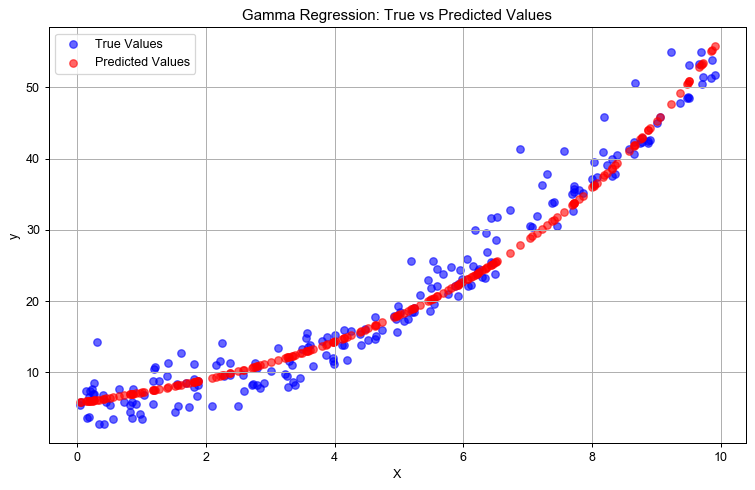

In [4]:
# 使用 TweedieRegressor 建立 Gamma Regression 模型
# label: "TweedieRegressor" and title: "Gamma Regression Model"
from sklearn.metrics import mean_squared_error

# 创建模型实例, power=2 表示目标变量服从 Gamma 分布, link='log' 是对数链接函数的常用选择
gamma_reg = TweedieRegressor(power=2, alpha=0.5, link='log', max_iter=1000)

# 训练模型
gamma_reg.fit(X_train, y_train)

# 使用训练好的模型进行预测
y_pred = gamma_reg.predict(X_test)

# 评价模型效果
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# 绘制预测值与真实值的对比图
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='True Values')
plt.scatter(X_test, y_pred, color='red', alpha=0.6, label='Predicted Values')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Gamma Regression: True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

- 使用 `TweedieRegressor` 来构建模型，其中 `power=2` 参数设置目标变量服从 Gamma 分布，`link='log'` 表示采用对数链接函数；
- 利用划分好的训练数据训练模型，并对测试集数据进行预测；
- 最后计算均方误差（MSE）来评估模型效果，并用散点图展示预测值和真实值之间的关系。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

#### 模型应用讲解

在实际应用中，伽玛回归模型能很好地处理具有明显右偏特性的响应变量。例如在保险精算中，赔付金额通常呈现右偏分布，此时应用伽玛回归模型能够更准确地描述数据分布，提升预测性能。另外在医疗领域，生存分析或治疗效果评估数据也常常呈现伽玛分布性质，借助这种模型可以更有效地提取特征和建立风险预估模型。

通过本示例可以看出：

- 数据生成部分体现了伽玛分布噪声的产生机制；
- 模型使用 TweedieRegressor 即实现了伽玛回归的核心思想；
- 可视化结果直观展示了模型预测与真实数据之间的匹配情况，从而验证模型在处理伽玛分布数据上的有效性。

## 最后

我们从三个方面为初学者详细介绍了伽玛分布的知识：

1. **直观解释：**

   - 介绍了伽玛分布在实际生活中的直观意义，如排队时间、设备故障等待时间、自然事件的累计时间等。
   - 解释了伽玛分布的参数及其对形态的影响，利用图形展示了不同参数下分布的形态特点。
2. **公式推导：**

   - 详细讲解了伽玛函数的定义与性质，并阐明了如何通过多重独立指数分布变量相加得到伽玛分布的概率密度函数。
   - 通过归一化积分的推导确定了概率密度函数的形式，并进一步推导了分布的累积分布函数、均值和方差等重要统计量。
3. **Python 实现：**

   - 介绍了如何用 NumPy 生成伽玛分布数据，并利用 Matplotlib 绘制直方图与理论密度曲线。
   - 展示了基于 TweedieRegressor 的 Gamma Regression 模型如何应用于实际数据建模，包括数据预处理、模型训练、预测及可视化展示。
   - 强调了伽玛分布在保险精算、医学生存分析等领域中机器学习应用的重要性。

通过以上内容，希望能够帮助大家从直观认识到数学推导，再到编程实践全面理解伽玛分布的内涵及应用场景。伽玛分布不仅在理论上具有严密性，更在实际应用中展现出强大的实用性。